# Brain Tumor Classifier Training Pipeline

This notebook contains the complete TensorFlow/Keras training pipeline using transfer learning. 
- Supports **EfficientNet-B3** and **EfficientNet-B0**.
- Sets up data augmentations (flips, rotations, zoom).
- Computes class weights to handle imbalances.
- Employs mixed precision training for GPU acceleration.
- Runs training in two stages (Head training and Fine-tuning).

In [1]:
import os
import sys
import random
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Add root directory to path so training utils can be loaded
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from training.data_loader import get_data_loaders, calculate_class_weights

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.20.0


### 1. Configure Seeds, Precision, and Hyperparameters

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    tf.config.experimental.enable_op_determinism()

def setup_mixed_precision():
    gpus = tf.config.list_physical_devices("GPU")
    if gpus:
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            policy = tf.keras.mixed_precision.Policy("mixed_float16")
            tf.keras.mixed_precision.set_global_policy(policy)
            print("[System] GPU acceleration detected. Mixed precision (float16) enabled.")
        except Exception as e:
            print(f"[System] Warning: Failed to initialize GPU config: {str(e)}")
    else:
        print("[System] No GPU detected. Training will run on CPU in float32.")

set_seed(42)
setup_mixed_precision()

# Define training parameters
MODEL_TYPE = "efficientnet_b3" # Options: "efficientnet_b3", "efficientnet_b0"
BATCH_SIZE = 32
IMAGE_SIZE = 224
EPOCHS_HEAD = 10
EPOCHS_FT = 15
LR_HEAD = 1e-3
LR_FT = 1e-5

[System] No GPU detected. Training will run on CPU in float32.


### 2. Load MRI Scan Datasets

In [3]:
# Set relative paths to dataset folders
train_dir = os.path.abspath(os.path.join(os.getcwd(), "..", "Brain Tumor data", "Training"))
test_dir = os.path.abspath(os.path.join(os.getcwd(), "..", "Brain Tumor data", "Testing"))

train_ds, test_ds = get_data_loaders(
    train_dir=train_dir,
    test_dir=test_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

class_weights = calculate_class_weights(train_dir=train_dir)

Found 5712 files belonging to 4 classes.
Found 1311 files belonging to 4 classes.
[DataLoader] Calculated Class Counts: {'glioma': 1321, 'meningioma': 1339, 'notumor': 1595, 'pituitary': 1457}
[DataLoader] Calculated Class Weights: {0: 1.080999242997729, 1: 1.0664675130694548, 2: 0.8952978056426333, 3: 0.9800960878517502}


### 3. Build Transfer Learning Model

In [4]:
def build_model(model_type: str, num_classes: int = 4, image_size: int = 224):
    img_augmentation = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal_and_vertical"),
        tf.keras.layers.RandomRotation(0.15),
        tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
        tf.keras.layers.RandomZoom(0.1),
        tf.keras.layers.RandomContrast(0.1)
    ], name="img_augmentation")

    inputs = tf.keras.layers.Input(shape=(image_size, image_size, 3))
    x = img_augmentation(inputs)
    
    if model_type.lower() == "efficientnet_b0":
        base_model = tf.keras.applications.EfficientNetB0(include_top=False, weights="imagenet", input_tensor=x)
    elif model_type.lower() == "efficientnet_b3":
        base_model = tf.keras.applications.EfficientNetB3(include_top=False, weights="imagenet", input_tensor=x)
    else:
        raise ValueError(f"Unsupported model type: {model_type}")
    
    base_model.trainable = False
    
    x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    x = tf.keras.layers.Dense(256, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    
    # Output layers must be float32 in mixed precision
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax", dtype="float32", name="predictions")(x)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs, name=f"BrainTumorClassifier_{model_type}")
    return model, base_model

model, base_model = build_model(MODEL_TYPE, num_classes=4, image_size=IMAGE_SIZE)
model.summary()

Model: "BrainTumorClassifier_efficientnet_b3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)               ┃ Output Shape            ┃        Param # ┃ Connected to            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)   │ (None, 224, 224, 3)     │              0 │ -                       │
├────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ img_augmentation           │ (None, 224, 224, 3)     │              0 │ input_layer[0][0]       │
│ (Sequential)               │                         │                │                         │
├────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ rescaling (Rescaling)      │ (None, 224, 224, 3)     │              0 │ img_augmentation[0][0]  │
├────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ normalization              │ (None, 224, 224, 3)     │              7 │ rescaling[0][0]         │
│ (Normalization)            │                         │                │                         │
├────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ rescaling_1 (Rescaling)    │ (None, 224, 224, 3)     │              0 │ normalization[0][0]     │
├────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ stem_conv_pad              │ (None, 225, 225, 3)     │              0 │ rescaling_1[0][0]       │
│ (ZeroPadding2D)            │                         │                │                         │
├────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ stem_conv (Conv2D)         │ (None, 112, 112, 40)    │          1,080 │ stem_conv_pad[0][0]     │
├────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ stem_bn                    │ (None, 112, 112, 40)    │            160 │ stem_conv[0][0]         │
│ (BatchNormalization)       │                         │                │                         │
├────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ stem_activation            │ (None, 112, 112, 40)    │              0 │ stem_bn[0][0]           │
│ (Activation)               │                         │                │                         │
├────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block1a_dwconv             │ (None, 112, 112, 40)    │            360 │ stem_activation[0][0]   │
│ (DepthwiseConv2D)          │                         │                │                         │
├────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block1a_bn                 │ (None, 112, 112, 40)    │            160 │ block1a_dwconv[0][0]    │
│ (BatchNormalization)       │                         │                │                         │
├────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block1a_activation         │ (None, 112, 112, 40)    │              0 │ block1a_bn[0][0]        │
│ (Activation)               │                         │                │                         │
├────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block1a_se_squeeze         │ (None, 40)              │              0 │ block1a_activation[0][… │
│ (GlobalAveragePooling2D)   │                         │                │                         │
├────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block1a_se_reshape         │ (None, 1, 1, 40)        │              0 │ block1a_se_squeeze[0][… │
│ (Reshape)                  │                         │                │                         │


 Total params: 11,184,179 (42.66 MB)

 Trainable params: 397,572 (1.52 MB)

 Non-trainable params: 10,786,607 (41.15 MB)

### 4. Stage 1: Train Classification Head

In [5]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_HEAD),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_checkpoint_path = os.path.abspath(os.path.join(os.getcwd(), "..", "models", "best_model.h5"))
os.makedirs(os.path.dirname(model_checkpoint_path), exist_ok=True)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2, verbose=1),
    tf.keras.callbacks.ModelCheckpoint(filepath=model_checkpoint_path, monitor="val_accuracy", save_best_only=True, mode="max", verbose=1)
]

print("Training the custom head for a few epochs...")
history_head = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS_HEAD,
    class_weight=class_weights,
    callbacks=callbacks
)

Training the custom head for a few epochs...
Epoch 1/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 923ms/step - accuracy: 0.6807 - loss: 1.0233
Epoch 1: val_accuracy improved from None to 0.73074, saving model to C:\Users\dabee\OneDrive\Documents\Brain Tumor Detection System\models\best_model.h5



Epoch 1: finished saving model to C:\Users\dabee\OneDrive\Documents\Brain Tumor Detection System\models\best_model.h5
179/179 ━━━━━━━━━━━━━━━━━━━━ 240s 1s/step - accuracy: 0.7475 - loss: 0.8220 - val_accuracy: 0.7307 - val_loss: 0.7262 - learning_rate: 0.0010
Epoch 2/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 908ms/step - accuracy: 0.8053 - loss: 0.6022
Epoch 2: val_accuracy improved from 0.73074 to 0.77498, saving model to C:\Users\dabee\OneDrive\Documents\Brain Tumor Detection System\models\best_model.h5



Epoch 2: finished saving model to C:\Users\dabee\OneDrive\Documents\Brain Tumor Detection System\models\best_model.h5
179/179 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - accuracy: 0.8118 - loss: 0.5728 - val_accuracy: 0.7750 - val_loss: 0.6683 - learning_rate: 0.0010
Epoch 3/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 931ms/step - accuracy: 0.8201 - loss: 0.5165
Epoch 3: val_accuracy did not improve from 0.77498
179/179 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - accuracy: 0.8269 - loss: 0.4882 - val_accuracy: 0.7704 - val_loss: 0.7386 - learning_rate: 0.0010
Epoch 4/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 885ms/step - accuracy: 0.8346 - loss: 0.4645
Epoch 4: val_accuracy improved from 0.77498 to 0.80931, saving model to C:\Users\dabee\OneDrive\Documents\Brain Tumor Detection System\models\best_model.h5



Epoch 4: finished saving model to C:\Users\dabee\OneDrive\Documents\Brain Tumor Detection System\models\best_model.h5
179/179 ━━━━━━━━━━━━━━━━━━━━ 190s 1s/step - accuracy: 0.8389 - loss: 0.4467 - val_accuracy: 0.8093 - val_loss: 0.5670 - learning_rate: 0.0010
Epoch 5/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 889ms/step - accuracy: 0.8382 - loss: 0.4403
Epoch 5: val_accuracy improved from 0.80931 to 0.81922, saving model to C:\Users\dabee\OneDrive\Documents\Brain Tumor Detection System\models\best_model.h5



Epoch 5: finished saving model to C:\Users\dabee\OneDrive\Documents\Brain Tumor Detection System\models\best_model.h5
179/179 ━━━━━━━━━━━━━━━━━━━━ 192s 1s/step - accuracy: 0.8416 - loss: 0.4207 - val_accuracy: 0.8192 - val_loss: 0.5405 - learning_rate: 0.0010
Epoch 6/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 918ms/step - accuracy: 0.8467 - loss: 0.4270
Epoch 6: val_accuracy did not improve from 0.81922
179/179 ━━━━━━━━━━━━━━━━━━━━ 196s 1s/step - accuracy: 0.8494 - loss: 0.4081 - val_accuracy: 0.7994 - val_loss: 0.6421 - learning_rate: 0.0010
Epoch 7/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 858ms/step - accuracy: 0.8566 - loss: 0.3849
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.

Epoch 7: val_accuracy did not improve from 0.81922
179/179 ━━━━━━━━━━━━━━━━━━━━ 185s 1s/step - accuracy: 0.8619 - loss: 0.3800 - val_accuracy: 0.8093 - val_loss: 0.6021 - learning_rate: 0.0010
Epoch 8/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 865ms/step - accuracy: 0.8728 - loss: 0.3647
Epoch 8: va


Epoch 9: finished saving model to C:\Users\dabee\OneDrive\Documents\Brain Tumor Detection System\models\best_model.h5
179/179 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - accuracy: 0.8824 - loss: 0.3336 - val_accuracy: 0.8299 - val_loss: 0.4707 - learning_rate: 2.0000e-04
Epoch 10/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 903ms/step - accuracy: 0.8785 - loss: 0.3303
Epoch 10: val_accuracy did not improve from 0.82990
179/179 ━━━━━━━━━━━━━━━━━━━━ 193s 1s/step - accuracy: 0.8757 - loss: 0.3304 - val_accuracy: 0.8299 - val_loss: 0.4727 - learning_rate: 2.0000e-04
Restoring model weights from the end of the best epoch: 9.


### 5. Stage 2: Fine-Tuning the Base Model

In [6]:
if EPOCHS_FT > 0:
    print("Unfreezing base layers for fine-tuning...")
    base_model.trainable = True
    
    # Keep BN layers frozen for stability
    for layer in base_model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
            
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LR_FT),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
)
    
    history_ft = model.fit(
        train_ds,
        validation_data=test_ds,
        epochs=EPOCHS_FT,
        class_weight=class_weights,
        callbacks=callbacks
    )
    
    # Merge history
    for key in history_head.history.keys():
        history_head.history[key].extend(history_ft.history[key])
    
final_history = history_head

Unfreezing base layers for fine-tuning...
Epoch 1/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8892 - loss: 0.2983
Epoch 1: val_accuracy improved from 0.82990 to 0.84439, saving model to C:\Users\dabee\OneDrive\Documents\Brain Tumor Detection System\models\best_model.h5



Epoch 1: finished saving model to C:\Users\dabee\OneDrive\Documents\Brain Tumor Detection System\models\best_model.h5
179/179 ━━━━━━━━━━━━━━━━━━━━ 592s 3s/step - accuracy: 0.8953 - loss: 0.2845 - val_accuracy: 0.8444 - val_loss: 0.4374 - learning_rate: 1.0000e-05
Epoch 2/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9168 - loss: 0.2336
Epoch 2: val_accuracy improved from 0.84439 to 0.87338, saving model to C:\Users\dabee\OneDrive\Documents\Brain Tumor Detection System\models\best_model.h5



Epoch 2: finished saving model to C:\Users\dabee\OneDrive\Documents\Brain Tumor Detection System\models\best_model.h5
179/179 ━━━━━━━━━━━━━━━━━━━━ 511s 3s/step - accuracy: 0.9165 - loss: 0.2343 - val_accuracy: 0.8734 - val_loss: 0.3574 - learning_rate: 1.0000e-05
Epoch 3/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9150 - loss: 0.2272
Epoch 3: val_accuracy improved from 0.87338 to 0.89245, saving model to C:\Users\dabee\OneDrive\Documents\Brain Tumor Detection System\models\best_model.h5



Epoch 3: finished saving model to C:\Users\dabee\OneDrive\Documents\Brain Tumor Detection System\models\best_model.h5
179/179 ━━━━━━━━━━━━━━━━━━━━ 506s 3s/step - accuracy: 0.9226 - loss: 0.2068 - val_accuracy: 0.8924 - val_loss: 0.3013 - learning_rate: 1.0000e-05
Epoch 4/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9258 - loss: 0.2105
Epoch 4: val_accuracy improved from 0.89245 to 0.90313, saving model to C:\Users\dabee\OneDrive\Documents\Brain Tumor Detection System\models\best_model.h5



Epoch 4: finished saving model to C:\Users\dabee\OneDrive\Documents\Brain Tumor Detection System\models\best_model.h5
179/179 ━━━━━━━━━━━━━━━━━━━━ 497s 3s/step - accuracy: 0.9319 - loss: 0.1860 - val_accuracy: 0.9031 - val_loss: 0.2644 - learning_rate: 1.0000e-05
Epoch 5/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9320 - loss: 0.1711
Epoch 5: val_accuracy improved from 0.90313 to 0.91838, saving model to C:\Users\dabee\OneDrive\Documents\Brain Tumor Detection System\models\best_model.h5



Epoch 5: finished saving model to C:\Users\dabee\OneDrive\Documents\Brain Tumor Detection System\models\best_model.h5
179/179 ━━━━━━━━━━━━━━━━━━━━ 478s 3s/step - accuracy: 0.9370 - loss: 0.1655 - val_accuracy: 0.9184 - val_loss: 0.2385 - learning_rate: 1.0000e-05
Epoch 6/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9444 - loss: 0.1422
Epoch 6: val_accuracy did not improve from 0.91838
179/179 ━━━━━━━━━━━━━━━━━━━━ 477s 3s/step - accuracy: 0.9468 - loss: 0.1409 - val_accuracy: 0.9161 - val_loss: 0.2362 - learning_rate: 1.0000e-05
Epoch 7/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9488 - loss: 0.1456
Epoch 7: val_accuracy did not improve from 0.91838
179/179 ━━━━━━━━━━━━━━━━━━━━ 475s 3s/step - accuracy: 0.9543 - loss: 0.1341 - val_accuracy: 0.9108 - val_loss: 0.2509 - learning_rate: 1.0000e-05
Epoch 8/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9571 - loss: 0.1280
Epoch 8: val_accuracy improved from 0.91838 to 0.92220, saving model to C:\Users\dabee


Epoch 8: finished saving model to C:\Users\dabee\OneDrive\Documents\Brain Tumor Detection System\models\best_model.h5
179/179 ━━━━━━━━━━━━━━━━━━━━ 477s 3s/step - accuracy: 0.9571 - loss: 0.1215 - val_accuracy: 0.9222 - val_loss: 0.2311 - learning_rate: 1.0000e-05
Epoch 9/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9536 - loss: 0.1241
Epoch 9: val_accuracy improved from 0.92220 to 0.93059, saving model to C:\Users\dabee\OneDrive\Documents\Brain Tumor Detection System\models\best_model.h5



Epoch 9: finished saving model to C:\Users\dabee\OneDrive\Documents\Brain Tumor Detection System\models\best_model.h5
179/179 ━━━━━━━━━━━━━━━━━━━━ 505s 3s/step - accuracy: 0.9599 - loss: 0.1126 - val_accuracy: 0.9306 - val_loss: 0.1906 - learning_rate: 1.0000e-05
Epoch 10/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9583 - loss: 0.1146
Epoch 10: val_accuracy did not improve from 0.93059
179/179 ━━━━━━━━━━━━━━━━━━━━ 479s 3s/step - accuracy: 0.9604 - loss: 0.1093 - val_accuracy: 0.9291 - val_loss: 0.2152 - learning_rate: 1.0000e-05
Epoch 11/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9610 - loss: 0.1142
Epoch 11: val_accuracy improved from 0.93059 to 0.94813, saving model to C:\Users\dabee\OneDrive\Documents\Brain Tumor Detection System\models\best_model.h5



Epoch 11: finished saving model to C:\Users\dabee\OneDrive\Documents\Brain Tumor Detection System\models\best_model.h5
179/179 ━━━━━━━━━━━━━━━━━━━━ 474s 3s/step - accuracy: 0.9627 - loss: 0.1075 - val_accuracy: 0.9481 - val_loss: 0.1541 - learning_rate: 1.0000e-05
Epoch 12/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9674 - loss: 0.0915
Epoch 12: val_accuracy did not improve from 0.94813
179/179 ━━━━━━━━━━━━━━━━━━━━ 482s 3s/step - accuracy: 0.9683 - loss: 0.0895 - val_accuracy: 0.9451 - val_loss: 0.1771 - learning_rate: 1.0000e-05
Epoch 13/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9671 - loss: 0.0955
Epoch 13: val_accuracy improved from 0.94813 to 0.95652, saving model to C:\Users\dabee\OneDrive\Documents\Brain Tumor Detection System\models\best_model.h5



Epoch 13: finished saving model to C:\Users\dabee\OneDrive\Documents\Brain Tumor Detection System\models\best_model.h5
179/179 ━━━━━━━━━━━━━━━━━━━━ 476s 3s/step - accuracy: 0.9702 - loss: 0.0889 - val_accuracy: 0.9565 - val_loss: 0.1295 - learning_rate: 1.0000e-05
Epoch 14/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9745 - loss: 0.0843
Epoch 14: val_accuracy did not improve from 0.95652
179/179 ━━━━━━━━━━━━━━━━━━━━ 498s 3s/step - accuracy: 0.9746 - loss: 0.0784 - val_accuracy: 0.9519 - val_loss: 0.1452 - learning_rate: 1.0000e-05
Epoch 15/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9767 - loss: 0.0782
Epoch 15: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.

Epoch 15: val_accuracy did not improve from 0.95652
179/179 ━━━━━━━━━━━━━━━━━━━━ 475s 3s/step - accuracy: 0.9743 - loss: 0.0781 - val_accuracy: 0.9504 - val_loss: 0.1436 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 13.


### 6. Plot and Save Loss & Accuracy Curves

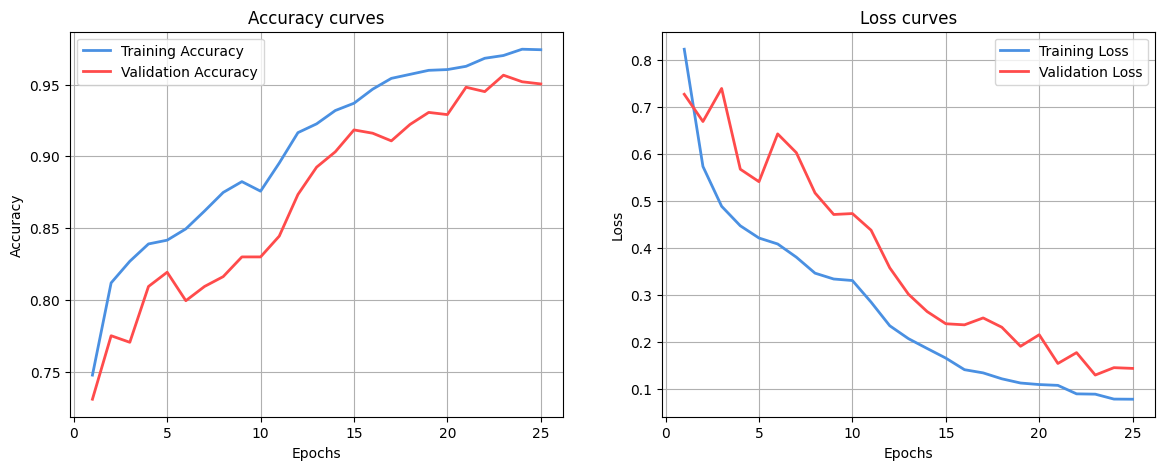

In [7]:
acc = final_history.history["accuracy"]
val_acc = final_history.history["val_accuracy"]
loss = final_history.history["loss"]
val_loss = final_history.history["val_loss"]
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy", color="#4A90E2", linewidth=2)
plt.plot(epochs_range, val_acc, label="Validation Accuracy", color="#FF4B4B", linewidth=2)
plt.title("Accuracy curves")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss", color="#4A90E2", linewidth=2)
plt.plot(epochs_range, val_loss, label="Validation Loss", color="#FF4B4B", linewidth=2)
plt.title("Loss curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

artifacts_dir = os.path.abspath(os.path.join(os.getcwd(), "..", "artifacts"))
os.makedirs(artifacts_dir, exist_ok=True)
plt.savefig(os.path.join(artifacts_dir, "training_plots.png"), dpi=300)
plt.show()